In [1]:
import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
if "I__hvgs" not in ds.RNA.feats.columns:
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
    )
ds.run_normalization(feat_key="hvgs")
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
)

Downloading bucket files: 31491651 / 31491651 complete

Downloading bytes: 31491651 / 31491651 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 150 / 150 complete

In [2]:
for t in (1, 2, 4):
    ds.cells.insert(
        f"CD4_imputed_t{t}",
        ds.get_imputed(feature_name="CD4", t=t),
        overwrite=True,
    )

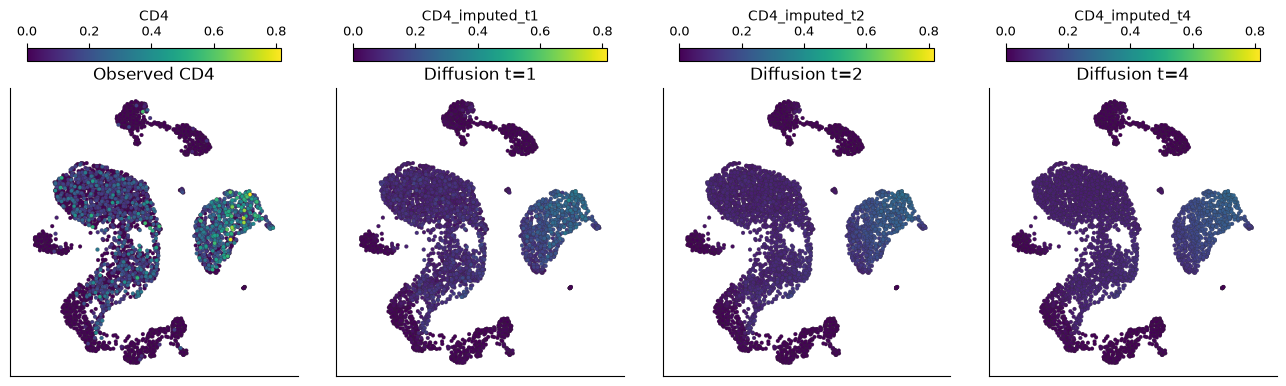

In [3]:
imputation_comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[
        "CD4",
        "CD4_imputed_t1",
        "CD4_imputed_t2",
        "CD4_imputed_t4",
    ],
    n_columns=4,
    color_scale=splt.ColorScale(scope="shared"),
    sort_values=True,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    imputation_comparison.axes.values(),
    ("Observed CD4", "Diffusion t=1", "Diffusion t=2", "Diffusion t=4"),
    strict=True,
):
    axis.set_title(title)